<a href="https://colab.research.google.com/github/txcagla/membership-inference-attacks-and-defense-mechanisms/blob/main/capstone_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MEMBERSHIP INFERENCE ATTACKS AND DEFENSE MECHANISMS ON CNN ARHITECTURE**

**LIBRARIES AND IMPORTS**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Project directory
save_path = '/content/drive/MyDrive/CapstoneProject'

if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"The folder has been created: {save_path}")

Installation of Necessary Libraries

In [ ]:
# PyTorch ve torchvision (CNN modeli ve dataset için)
!pip install torch torchvision

# Differential Privacy için Opacus
# Facebook/Meta tarafından geliştirilmiş, Differential Privacy (DP) uygulamak için özel olarak tasarlanmış bir kütüphane.
# Gradient clipping ve noise ekleme gibi işlemleri otomatik yapar
!pip install opacus

# Scikit-learn (Random Forest attack modeli ve metrikler için)
!pip install scikit-learn

# Ek yardımcı kütüphaneler
!pip install matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 7.0 MB/s eta 0:00:00


Importing Libraries

In [ ]:
# Hedef model (CNN) ve CIFAR-10 veri seti için
import torch
import torchvision

# Veri ön işleme (normalizasyon, tensör dönüşümü, veri artırma - augmentation)
import torchvision.transforms as transforms

# CNN katmanlarını (Conv2d, Pooling, Fully Connected) ve aktivasyon fonksiyonlarını (ReLU, Softmax) tanımlamak için
import torch.nn as nn
import torch.nn.functional as F

# Optimizasyon algoritmaları (SGD, Adam) - DP ve KD için kritik
import torch.optim as optim

# DataLoader: CIFAR-10'u batch'ler halinde modele beslemek için
# random_split: Eğitim, validasyon ve shadow modeller için eğitim-alt kümeleri oluşturmak amacıyla kullanılacak.
from torch.utils.data import DataLoader, random_split

# Differential Privacy (Opacus): Gardient clipping, noise ekleme, privacy budget hesaplama
from opacus import PrivacyEngine

# RandomForestClassifier: Shadow model-based membership inference attack'te kullanılacak asıl saldırı modeli.
# Inputu: Shadow modellerin çıktı vektörleri (örn. 10 sınıflı CIFAR-10 için 10 olasılık)
# Outputu: Üye mi/Değil mi(binary classification)
from sklearn.ensemble import RandomForestClassifier

# Metriklerin hesaplanması
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Progress bar: Eğitim döngülerinde ilerleme çubuğu (özellikle KD'de öğretmen-öğrenci eğitimi ve shadow modellerin eğitimi uzun sürebilir)
from tqdm import tqdm

# Görselleştirme için matplotlib: Karşılaştırmalı grafikler (3 savunma yöntemi için yan yana ROC eğrileri, accuracy bar plotları)
import matplotlib.pyplot as plt

# NumPy: Tensor'ları numpy array'e çevirmek için (Random Forest, numpy girdisi bekler)
import numpy as np

Device Control and Speedup Settings

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {device}")

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

Device used: cuda


Seed adjustment for reproducibility

In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # CNN operasyonlarını deterministik hale getirme
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed {seed} was successfully configured and cuDNN was put into deterministic mode.")

set_seed(42)

Seed 42 was successfully configured and cuDNN was put into deterministic mode.


**THE DATASET: CIFAR10**

Transform (Normalization + Augmentation)

In [ ]:
# Train için: Data Augmentation overfitting'i azaltır.
# NOT: Savunmasız modelde overfitting ne kadar fazlaysa, MIA o kadar başarılı olur.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Test/Validation/Shadow için: Gerçek dağılımı korumak için augmentation yapmıyoruz.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Dataset Upload and Strategic Partitioning

In [10]:
import torchvision
from torch.utils.data import random_split, Dataset

# 1. VERİ YÜKLEME
full_train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=False)
full_test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=False)

# 2. VERİ BÖLME STRATEJİSİ
# Target (25k) ve Shadow (25k) ayrımı
target_raw, shadow_raw = random_split(full_train_raw, [25000, 25000])

# Target model için Train/Val ayrımı (%80 - %20)
target_train_size = int(0.8 * len(target_raw))
target_val_size = len(target_raw) - target_train_size
target_train_data, target_val_data = random_split(target_raw, [target_train_size, target_val_size])

# 3. TRANSFORM WRAPPER
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# 4. DATASET NESNELERİNİN OLUŞTURULMASI
train_dataset = ApplyTransform(target_train_data, transform=train_transform)
val_dataset = ApplyTransform(target_val_data, transform=test_transform)
shadow_dataset = ApplyTransform(shadow_raw, transform=train_transform)
test_dataset = ApplyTransform(full_test_raw, transform=test_transform)

print(f"Target Train: {len(train_dataset)}, Target Val: {len(val_dataset)}")
print(f"Shadow Data: {len(shadow_dataset)}, Test Data: {len(test_dataset)}")

Target Train: 20000, Target Val: 5000
Shadow Data: 25000, Test Data: 10000


Creating a DataLoader

In [11]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
shadow_loader = DataLoader(shadow_dataset, batch_size=batch_size, shuffle=True)

print(f"Target Train size: {len(train_dataset)}")
print(f"Target Val size: {len(val_dataset)}")
print(f"Shadow Data size: {len(shadow_dataset)}")
print(f"Test size: {len(test_dataset)}")

Target Train size: 20000
Target Val size: 5000
Shadow Data size: 25000
Test size: 10000


Data Visualization

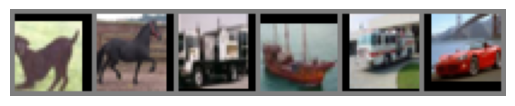

Labels: ['dog', 'horse', 'truck', 'ship', 'truck', 'automobile']


In [12]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()

images, labels = next(iter(train_loader))
imshow(torchvision.utils.make_grid(images[:6]))
print("Labels:", [classes[l] for l in labels[:6]])

**BASELINE CNN MODEL**

CNN Model Description (Opacus Compatible)

In [14]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Opacus, standart BatchNorm katmanlarını sevmez (grup bazlı gradyan hesapladığı için).
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # CIFAR-10'da 2 pool sonrası 32x32 -> 16x16 -> 8x8 olur.
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Daha genel bir düzleştirme
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

Train Function

In [15]:
# Fonksiyona 'privacy_engine' parametresi ekledik.
# DP eğitiminde epsilon değerini takip etmek için gerekecek.
def train(model, train_loader, optimizer, criterion, device, privacy_engine=None):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Eğer DP kullanılıyorsa Privacy Budget (Epsilon) bilgisini yazdır
    if privacy_engine:
        epsilon = privacy_engine.get_epsilon(delta=1e-5)
        return avg_loss, epsilon

    return avg_loss, None

Evaluation Function

In [16]:
def validate_with_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(loader), 100 * correct / total

Create The Model and Define The Drive Path

In [17]:
save_path = '/content/drive/MyDrive/CapstoneProject' # Daha önce oluşturduğumuz klasör
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

Training Loop

In [18]:
num_epochs = 50
patience = 7
best_val_acc = 0
patience_counter = 0

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Baseline Model Training Begins...")

for epoch in range(num_epochs):
    # train fonksiyonu artık tuple döndürüyor
    train_loss, _ = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_with_loss(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Modeli hem yerel hem Drive'a kaydet
        torch.save(model.state_dict(), f'{save_path}/best_baseline_model.pth')
        torch.save(model.state_dict(), 'best_baseline_model.pth')
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or patience_counter == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Final Test
model.load_state_dict(torch.load('best_baseline_model.pth'))
_, test_acc = validate_with_loss(model, test_loader, criterion, device)
print(f"\nFinal Baseline Test Accuracy: {test_acc:.2f}%")

Baseline Model Training Begins...
Epoch [1/50] | Train Loss: 2.1046 | Val Acc: 33.70%
Epoch [2/50] | Train Loss: 1.8300 | Val Acc: 39.62%
Epoch [3/50] | Train Loss: 1.6745 | Val Acc: 44.82%
Epoch [4/50] | Train Loss: 1.5979 | Val Acc: 48.88%
Epoch [5/50] | Train Loss: 1.5395 | Val Acc: 50.50%
Epoch [6/50] | Train Loss: 1.4858 | Val Acc: 52.58%
Epoch [7/50] | Train Loss: 1.4437 | Val Acc: 53.42%
Epoch [8/50] | Train Loss: 1.4046 | Val Acc: 56.40%
Epoch [9/50] | Train Loss: 1.3671 | Val Acc: 58.04%
Epoch [10/50] | Train Loss: 1.3177 | Val Acc: 58.64%
Epoch [11/50] | Train Loss: 1.2798 | Val Acc: 61.02%
Epoch [13/50] | Train Loss: 1.2258 | Val Acc: 62.78%
Epoch [14/50] | Train Loss: 1.2036 | Val Acc: 64.86%
Epoch [15/50] | Train Loss: 1.1695 | Val Acc: 64.74%
Epoch [16/50] | Train Loss: 1.1492 | Val Acc: 65.96%
Epoch [17/50] | Train Loss: 1.1160 | Val Acc: 67.04%
Epoch [19/50] | Train Loss: 1.0811 | Val Acc: 67.82%
Epoch [20/50] | Train Loss: 1.0671 | Val Acc: 67.82%
Epoch [21/50] | Train

**Shadow Model Training**

In [19]:
print("Shadow Model Training Begins (Preparation of the Attacker)...")

shadow_model = CNNModel().to(device)
shadow_optimizer = optim.SGD(shadow_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
shadow_criterion = nn.CrossEntropyLoss()

# Shadow model için de benzer bir eğitim döngüsü
best_shadow_acc = 0
for epoch in range(50):
    s_loss, _ = train(shadow_model, shadow_loader, shadow_optimizer, shadow_criterion, device)
    _, s_acc = validate_with_loss(shadow_model, val_loader, shadow_criterion, device)

    if s_acc > best_shadow_acc:
        best_shadow_acc = s_acc
        torch.save(shadow_model.state_dict(), 'best_shadow_model.pth')

print(f"Shadow Model Training Completed. Best Val Acc: {best_shadow_acc:.2f}%")

Shadow Model Training Begins (Preparation of the Attacker)...
Shadow Model Training Completed. Best Val Acc: 76.72%


Attack Dataset Generation Function

In [20]:
def prepare_attack_data(model, member_loader, non_member_loader, device):
    model.eval()
    attack_x = []
    attack_y = []

    with torch.no_grad():
        # Üyeler (Etiket: 1)
        for images, _ in member_loader:
            images = images.to(device)
            outputs = F.softmax(model(images), dim=1) # Olasılık vektörleri
            attack_x.append(outputs.cpu().numpy())
            attack_y.append(np.ones(len(images)))

        # Üye Olmayanlar (Etiket: 0)
        for images, _ in non_member_loader:
            images = images.to(device)
            outputs = F.softmax(model(images), dim=1)
            attack_x.append(outputs.cpu().numpy())
            attack_y.append(np.zeros(len(images)))

    return np.vstack(attack_x), np.concatenate(attack_y)

Prepare Attack Data and Train Random Forest Model

In [21]:
# Shadow modelin kendi eğitim verisi (üyeler) ve hiç görmediği target_train_data (üye olmayanlar)
# Shadow loader üyeleri veriyor, val_loader'ı üye olmayanlar gibi kullanabiliriz
X_attack_train, y_attack_train = prepare_attack_data(shadow_model, shadow_loader, val_loader, device)

# Random Forest Saldırganı
attack_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
attack_clf.fit(X_attack_train, y_attack_train)

print("The attack model (Random Forest) has been trained.")

The attack model (Random Forest) has been trained.


Attack Testing For Target Model

In [22]:
print("MIA testing is being performed on the Target Model...")

# Target modelin üyeleri (train_loader) ve üye olmayanları (test_loader)
X_target_test, y_target_test = prepare_attack_data(model, train_loader, test_loader, device)

# Saldırı modelinden tahminleri al
y_pred_attack = attack_clf.predict(X_target_test)
y_prob_attack = attack_clf.predict_proba(X_target_test)[:, 1]

# Metrikleri hesapla
attack_acc = accuracy_score(y_target_test, y_pred_attack)
attack_auc = roc_auc_score(y_target_test, y_prob_attack)

print("\n" + "-"*30)
print("BASELINE MIA RESULTS")
print(f"Attack Accuracy: {attack_acc:.4f}")
print(f"Attack ROC-AUC Score: {attack_auc:.4f}")

MIA testing is being performed on the Target Model...

------------------------------
BASELINE MIA RESULTS
Attack Accuracy: 0.6668
Attack ROC-AUC Score: 0.5882


Roc Curve Visualization

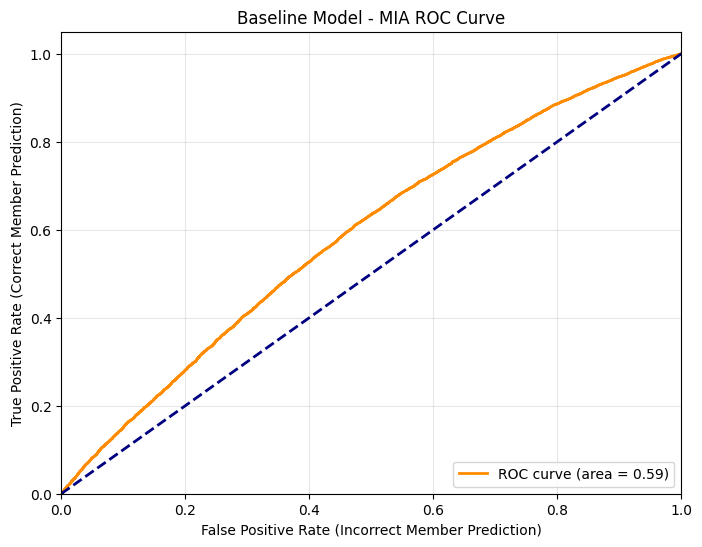

In [23]:
fpr, tpr, _ = roc_curve(y_target_test, y_prob_attack)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {attack_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Incorrect Member Prediction)')
plt.ylabel('True Positive Rate (Correct Member Prediction)')
plt.title('Baseline Model - MIA ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**DIFFERENTIAL PRIVACY (DP) WITH OPACUS**

DP Parameter Analysis and Comparison

NOISE LEVEL COMPARISON

In [24]:
import pandas as pd

def run_custom_dp(noise_val, exp_name):
    print(f"\n--- {exp_name} is running (Noise: {noise_val}) ---")

    # Model ve Optimizer Hazırlığı
    m_dp = CNNModel().to(device)
    opt_dp = optim.SGD(m_dp.parameters(), lr=0.05, momentum=0.9)
    crit_dp = nn.CrossEntropyLoss()

    pe = PrivacyEngine()
    m_dp, opt_dp, loader_dp = pe.make_private(
        module=m_dp, optimizer=opt_dp, data_loader=train_loader,
        noise_multiplier=noise_val, max_grad_norm=1.2
    )

    # Eğitim
    best_acc = 0
    for epoch in range(30):
        train(m_dp, loader_dp, opt_dp, crit_dp, device)
        _, v_acc = validate_with_loss(m_dp, val_loader, crit_dp, device)
        if v_acc > best_acc:
            best_acc = v_acc

    # MIA Testi (Gizliliği ölçmek için)
    X_mia, y_mia = prepare_attack_data(m_dp, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    # Final Epsilon Değeri
    eps = pe.get_epsilon(delta=1e-5)

    return {
        "Scenario": exp_name,
        "Noise": noise_val,
        "Test Acc (%)": f"{best_acc:.2f}",
        "MIA ROC-AUC": f"{auc_mia:.4f}",
        "Epsilon (ε)": f"{eps:.2f}"
    }

# Deneyleri Çalıştır
dp_scenarios = [
    (1.2, "Value 1"),
    (0.9, "Value 2"),
    (0.8, "Value 3"),
    (0.7, "Value 4"),
    (0.5, "Value 5")
]

all_results = []
for n, name in dp_scenarios:
    all_results.append(run_custom_dp(n, name))


--- Value 1 is running (Noise: 1.2) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Value 2 is running (Noise: 0.9) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Value 3 is running (Noise: 0.8) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Value 4 is running (Noise: 0.7) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Value 5 is running (Noise: 0.5) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Table of The Results

In [25]:
comparison_df = pd.DataFrame(all_results)

print("\n" + "-"*60)
print("DIFFERENTIAL PRIVACY PARAMETER COMPARISON TABLE")
print("-"*60)
display(comparison_df)


------------------------------------------------------------
DIFFERENTIAL PRIVACY PARAMETER COMPARISON TABLE
------------------------------------------------------------


,Scenario,Noise,Test Acc (%),MIA ROC-AUC,Epsilon (ε)
0,Value 1,1.2,29.62,0.4896,1.79
1,Value 2,0.9,36.06,0.5152,3.05
2,Value 3,0.8,36.98,0.5091,4.03
3,Value 4,0.7,41.74,0.5471,5.83
4,Value 5,0.5,45.62,0.5633,17.99


COMPARISON OF CLIPPING VALUES

In [26]:
def run_clipping_experiment(clip_val, noise_val=0.8):
    exp_name = f"Clip-{clip_val}"
    print(f"\n--- {exp_name} is running (Noise constant: {noise_val}) ---")

    # Her seferinde temiz bir model oluştur
    m_clip = CNNModel().to(device)
    opt_clip = optim.SGD(m_clip.parameters(), lr=0.05, momentum=0.9)
    crit_clip = nn.CrossEntropyLoss()

    pe_clip = PrivacyEngine()
    m_clip, opt_clip, loader_clip = pe_clip.make_private(
        module=m_clip,
        optimizer=opt_clip,
        data_loader=train_loader,
        noise_multiplier=noise_val,
        max_grad_norm=clip_val
    )

    best_acc = 0
    # Kararlı bir trend görmek için 30 epoch yeterli
    for epoch in range(30):
        train(m_clip, loader_clip, opt_clip, crit_clip, device)
        _, v_acc = validate_with_loss(m_clip, val_loader, crit_clip, device)
        if v_acc > best_acc:
            best_acc = v_acc

    # MIA Testi (Gizlilik ölçümü)
    X_mia, y_mia = prepare_attack_data(m_clip, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    eps = pe_clip.get_epsilon(delta=1e-5)

    return {
        "Clip Threshold": clip_val,
        "Test Acc (%)": f"{best_acc:.2f}",
        "MIA ROC-AUC": f"{auc_mia:.4f}",
        "Epsilon (ε)": f"{eps:.2f}"
    }

# Farklı Clipping değerlerini test etme
clipping_values = [0.1, 0.5, 1.0, 1.5, 2.0]
clipping_results = []

for c in clipping_values:
    res = run_clipping_experiment(c)
    clipping_results.append(res)


--- Clip-0.1 is running (Noise constant: 0.8) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Clip-0.5 is running (Noise constant: 0.8) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Clip-1.0 is running (Noise constant: 0.8) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Clip-1.5 is running (Noise constant: 0.8) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.



--- Clip-2.0 is running (Noise constant: 0.8) ---


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Table of The Results

In [27]:
df_clipping = pd.DataFrame(clipping_results)
print("\n" + "="*60)
print("DP CLIPPING (GRAD_NORM) IMPACT ANALYSIS")
print("="*60)
display(df_clipping)


DP CLIPPING (GRAD_NORM) IMPACT ANALYSIS


,Clip Threshold,Test Acc (%),MIA ROC-AUC,Epsilon (ε)
0,0.1,38.76,0.5195,4.03
1,0.5,44.12,0.5547,4.03
2,1.0,39.74,0.5235,4.03
3,1.5,35.08,0.5329,4.03
4,2.0,32.34,0.5144,4.03


BATCH SIZE VALUE COMPARISON

In [28]:
def run_batch_size_experiment(bs_val, noise_val=0.8, clip_val=1.0):
    exp_name = f"Batch-{bs_val}"
    print(f"\n--- {exp_name} is running (Noise: {noise_val}, Clip: {clip_val}) ---")

    # Batch size'a göre DataLoader'ı yeniden oluştur
    # train_dataset daha önce tanımladığımız Target Train verisidir
    temp_loader = DataLoader(train_dataset, batch_size=bs_val, shuffle=True, drop_last=True)

    m_bs = CNNModel().to(device)
    opt_bs = optim.SGD(m_bs.parameters(), lr=0.05, momentum=0.9)
    crit_bs = nn.CrossEntropyLoss()

    pe_bs = PrivacyEngine()
    m_bs, opt_bs, loader_bs = pe_bs.make_private(
        module=m_bs,
        optimizer=opt_bs,
        data_loader=temp_loader,
        noise_multiplier=noise_val,
        max_grad_norm=clip_val
    )

    best_acc = 0
    for epoch in range(30):
        # train fonksiyonumuzu yeni loader ile çağırıyoruz
        train(m_bs, loader_bs, opt_bs, crit_bs, device)
        _, v_acc = validate_with_loss(m_bs, val_loader, crit_bs, device)
        if v_acc > best_acc:
            best_acc = v_acc

    # MIA Testi
    X_mia, y_mia = prepare_attack_data(m_bs, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    eps = pe_bs.get_epsilon(delta=1e-5)

    return {
        "Batch Size": bs_val,
        "Test Acc (%)": f"{best_acc:.2f}",
        "MIA ROC-AUC": f"{auc_mia:.4f}",
        "Epsilon (ε)": f"{eps:.2f}"
    }

# Farklı Batch Size değerlerini test et
batch_sizes = [32, 64, 128, 256]
batch_results = []

for b in batch_sizes:
    res = run_batch_size_experiment(b)
    batch_results.append(res)

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



--- Batch-32 is running (Noise: 0.8, Clip: 1.0) ---


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



--- Batch-64 is running (Noise: 0.8, Clip: 1.0) ---


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



--- Batch-128 is running (Noise: 0.8, Clip: 1.0) ---


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



--- Batch-256 is running (Noise: 0.8, Clip: 1.0) ---


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Table of The Results

In [29]:
df_batch = pd.DataFrame(batch_results)
print("\n" + "="*60)
print("DP Batch Size Impact Analysis")
print("="*60)
display(df_batch)


DP Batch Size Impact Analysis


,Batch Size,Test Acc (%),MIA ROC-AUC,Epsilon (ε)
0,32,11.84,0.4949,1.79
1,64,23.74,0.4983,2.69
2,128,40.18,0.5315,4.04
3,256,47.78,0.5868,6.08


MEASURING THE IMPACT OF PARTIAL DP

In [30]:
def run_partial_dp_experiment():
    BS_VAL = 128
    NOISE_VAL = 0.8
    CLIP_VAL = 1.0
    EPOCH_VAL = 30

    print(f"\n--- Partial is running (Epoch: {EPOCH_VAL}, Noise: {NOISE_VAL}, Clip: {CLIP_VAL}, BS: {BS_VAL}) ---")

    # 1. Modeli oluştur
    model_partial = CNNModel().to(device)

    # 2. Conv katmanlarını dondur (Feature Extraction kısmı gürültüden muaf tutuluyor)
    for name, param in model_partial.named_parameters():
        if "conv" in name:
            param.requires_grad = False

    # 3. Batch size uyumlu yeni loader
    temp_loader = DataLoader(train_dataset, batch_size=BS_VAL, shuffle=True, drop_last=True)

    # 4. Sadece eğitilebilir parametreleri (FC) Optimizer'a ver
    optimizer_partial = optim.SGD(
        filter(lambda p: p.requires_grad, model_partial.parameters()),
        lr=0.05,
        momentum=0.9
    )

    criterion_partial = nn.CrossEntropyLoss()

    # 5. Opacus hazırlığı
    privacy_engine_p = PrivacyEngine()

    model_partial, optimizer_partial, loader_partial = privacy_engine_p.make_private(
        module=model_partial,
        optimizer=optimizer_partial,
        data_loader=temp_loader,
        noise_multiplier=NOISE_VAL,
        max_grad_norm=CLIP_VAL
    )

    best_acc = 0
    for epoch in range(EPOCH_VAL):
        train(model_partial, loader_partial, optimizer_partial, criterion_partial, device)
        _, v_acc = validate_with_loss(model_partial, val_loader, criterion_partial, device)
        if v_acc > best_acc:
            best_acc = v_acc

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{EPOCH_VAL}] | Val Acc: {v_acc:.2f}%")

    # 6. MIA Testi
    X_mia, y_mia = prepare_attack_data(model_partial, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    eps = privacy_engine_p.get_epsilon(delta=1e-5)

    return {
        "Method": "Partial DP (Only FC)",
        "Test Acc (%)": f"{best_acc:.2f}",
        "MIA ROC-AUC": f"{auc_mia:.4f}",
        "Epsilon (ε)": f"{eps:.2f}"
    }

# Deneyi çalıştır
partial_results = run_partial_dp_experiment()

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



--- Partial is running (Epoch: 30, Noise: 0.8, Clip: 1.0, BS: 128) ---


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch [5/30] | Val Acc: 35.16%
Epoch [10/30] | Val Acc: 37.38%
Epoch [15/30] | Val Acc: 38.96%
Epoch [20/30] | Val Acc: 38.56%
Epoch [25/30] | Val Acc: 39.32%
Epoch [30/30] | Val Acc: 39.22%


Table of The Results

In [31]:
import pandas as pd
print("\n" + "="*60)
print("PARTIAL DP VS FULL DP ANALYSIS")
print("="*60)
df_partial = pd.DataFrame([partial_results])
display(df_partial)


PARTIAL DP VS FULL DP ANALYSIS


,Method,Test Acc (%),MIA ROC-AUC,Epsilon (ε)
0,Partial DP (Only FC),39.58,0.5493,4.04


EPOCH ANALYSIS

In [32]:
def run_fine_grained_epoch_analysis():
    # En İyi Parametre Setimiz
    BS_VAL = 128
    NOISE_VAL = 0.8
    CLIP_VAL = 1.0
    MAX_EPOCH = 50
    STEP = 5 # Analiz sıklığı

    print(f"\n--- Epoch Analysis is Being Initiated (Step: {STEP}) ---")

    # 1. Model ve Partial DP Hazırlığı
    model_fine = CNNModel().to(device)
    for name, param in model_fine.named_parameters():
        if "conv" in name:
            param.requires_grad = False

    temp_loader = DataLoader(train_dataset, batch_size=BS_VAL, shuffle=True, drop_last=True)

    optimizer_fine = optim.SGD(
        filter(lambda p: p.requires_grad, model_fine.parameters()),
        lr=0.05, momentum=0.9
    )
    criterion_fine = nn.CrossEntropyLoss()

    privacy_engine_fine = PrivacyEngine()
    model_fine, optimizer_fine, loader_fine = privacy_engine_fine.make_private(
        module=model_fine,
        optimizer=optimizer_fine,
        data_loader=temp_loader,
        noise_multiplier=NOISE_VAL,
        max_grad_norm=CLIP_VAL
    )

    fine_results = []

    for epoch in range(1, MAX_EPOCH + 1):
        # Eğitim adımı
        train(model_fine, loader_fine, optimizer_fine, criterion_fine, device)
        _, val_acc = validate_with_loss(model_fine, val_loader, criterion_fine, device)

        # Her 5 epoch'ta bir detaylı ölçüm al
        if epoch % STEP == 0 or epoch == 1:
            # MIA Testi
            X_mia, y_mia = prepare_attack_data(model_fine, train_loader, test_loader, device)
            y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
            auc_mia = roc_auc_score(y_mia, y_prob_mia)

            # Gizlilik Bütçesi
            eps = privacy_engine_fine.get_epsilon(delta=1e-5)

            print(f"Epoch {epoch:02d} | Accuracy: {val_acc:.2f}% | MIA AUC: {auc_mia:.4f} | Epsilon: {eps:.2f}")

            fine_results.append({
                "Epoch": epoch,
                "Test Acc (%)": val_acc,
                "MIA ROC-AUC": auc_mia,
                "Epsilon (ε)": eps
            })

    return pd.DataFrame(fine_results)

# Analizi çalıştır
df_fine_analysis = run_fine_grained_epoch_analysis()

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(



--- Epoch Analysis is Being Initiated (Step: 5) ---


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 01 | Accuracy: 25.58% | MIA AUC: 0.4386 | Epsilon: 1.17


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


...

Epoch 40 | Accuracy: 40.72% | MIA AUC: 0.5739 | Epsilon: 4.68


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 45 | Accuracy: 40.40% | MIA AUC: 0.5559 | Epsilon: 4.98


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 50 | Accuracy: 41.22% | MIA AUC: 0.5623 | Epsilon: 5.26


Table of The Results

In [33]:
print("\n" + "="*65)
print("EPOCH ANALYSIS: PRIVACY AND PERFORMANCE MONITORING")
print("="*65)
display(df_fine_analysis)


EPOCH ANALYSIS: PRIVACY AND PERFORMANCE MONITORING


,Epoch,Test Acc (%),MIA ROC-AUC,Epsilon (ε)
0,1,25.58,0.438559,1.168422
1,5,34.02,0.488311,1.860971
2,10,38.62,0.551782,2.430117
3,15,38.00,0.569251,2.900320
4,20,39.36,0.581201,3.315111
5,25,40.04,0.579124,3.692520
6,30,40.06,0.583785,4.042404
7,35,39.92,0.586987,4.370906
8,40,40.72,0.573850,4.682167
9,45,40.40,0.555873,4.979141


**KNOWLEDGE DISTILLATION (KD)**

TEMPERATURE (T) EFFECT ANALYSIS

In [34]:
def distillation_loss(student_outputs, teacher_outputs, labels, T=4.0, alpha=0.5):
    # 1. Standart Cross Entropy (Hard labels)
    hard_loss = F.cross_entropy(student_outputs, labels)

    # 2. KL Divergence (Soft labels - Öğretmenden gelen bilgi)
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_outputs / T, dim=1),
        F.softmax(teacher_outputs / T, dim=1)
    ) * (alpha * T * T) # T^2 ile ölçeklendirme gradyan dengesi için kritiktir

    return (1. - alpha) * hard_loss + soft_loss

def run_kd_temperature_experiment(T_val, alpha_val=0.7):
    exp_name = f"KD-T-{T_val}"
    print(f"\n--- {exp_name} is running (Alpha: {alpha_val}) ---")

    # Öğretmen modeli hazırla (Baseline modeliniz)
    teacher_model = CNNModel().to(device)
    teacher_model.load_state_dict(torch.load(f'{save_path}/best_baseline_model.pth'))
    teacher_model.eval()

    # Öğrenci modeli sıfırdan oluştur
    student_model = CNNModel().to(device)
    optimizer_kd = optim.SGD(student_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    num_epochs_kd = 30 # Karşılaştırma için 30 epoch yeterlidir
    best_acc = 0

    for epoch in range(num_epochs_kd):
        student_model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer_kd.zero_grad()

            with torch.no_grad():
                teacher_outputs = teacher_model(images)
            student_outputs = student_model(images)

            # KD Kayıp Fonksiyonu
            loss = distillation_loss(student_outputs, teacher_outputs, labels, T=T_val, alpha=alpha_val)
            loss.backward()
            optimizer_kd.step()

        # Validasyon
        _, val_acc = validate_with_loss(student_model, val_loader, nn.CrossEntropyLoss(), device)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(student_model.state_dict(), f'temp_kd_T{T_val}.pth')

    # MIA Testi (Gizlilik Ölçümü)
    student_model.load_state_dict(torch.load(f'temp_kd_T{T_val}.pth'))
    X_mia, y_mia = prepare_attack_data(student_model, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    return {
        "Temperature (T)": T_val,
        "Test Acc (%)": f"{best_acc:.2f}",
        "MIA ROC-AUC": f"{auc_mia:.4f}"
    }

# Farklı T değerlerini test et
t_values = [1, 4, 10, 20]
kd_t_results = []

for t in t_values:
    res = run_kd_temperature_experiment(t)
    kd_t_results.append(res)


--- KD-T-1 is running (Alpha: 0.7) ---

--- KD-T-4 is running (Alpha: 0.7) ---

--- KD-T-10 is running (Alpha: 0.7) ---

--- KD-T-20 is running (Alpha: 0.7) ---


Table of The Results

In [35]:
import pandas as pd
df_kd_t = pd.DataFrame(kd_t_results)
print("\n" + "="*50)
print("KD TEMPERATURE ANALYSIS RESULTS")
print("="*50)
print(df_kd_t)


KD TEMPERATURE ANALYSIS RESULTS
   Temperature (T) Test Acc (%) MIA ROC-AUC
0                1        71.68      0.5807
1                4        73.10      0.5946
2               10        72.72      0.5854
3               20        73.12      0.5960


ALPHA (α) EFFECT ANALYSIS

In [37]:
def run_kd_alpha_experiment(alpha_val, T_fixed=10.0):
    exp_name = f"KD-Alpha-{alpha_val}"
    print(f"\n--- {exp_name} is running (Temperature: {T_fixed}) ---")

    # Öğretmen modeli hazırla
    teacher_model = CNNModel().to(device)
    teacher_model.load_state_dict(torch.load(f'{save_path}/best_baseline_model.pth'))
    teacher_model.eval()

    # Öğrenci modeli sıfırdan oluştur
    student_model = CNNModel().to(device)
    optimizer_kd = optim.SGD(student_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    num_epochs_kd = 30
    best_acc = 0

    for epoch in range(num_epochs_kd):
        student_model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer_kd.zero_grad()

            with torch.no_grad():
                teacher_outputs = teacher_model(images)
            student_outputs = student_model(images)

            # Kayıp Fonksiyonu (Daha önce tanımladığın distillation_loss kullanılıyor)
            loss = distillation_loss(student_outputs, teacher_outputs, labels, T=T_fixed, alpha=alpha_val)
            loss.backward()
            optimizer_kd.step()

        # Validasyon
        _, val_acc = validate_with_loss(student_model, val_loader, nn.CrossEntropyLoss(), device)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(student_model.state_dict(), f'temp_kd_A{alpha_val}.pth')

    # MIA Testi
    student_model.load_state_dict(torch.load(f'temp_kd_A{alpha_val}.pth'))
    X_mia, y_mia = prepare_attack_data(student_model, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    return {
        "Alpha (α)": alpha_val,
        "Test Acc (%)": f"{best_acc:.2f}",
        "MIA ROC-AUC": f"{auc_mia:.4f}"
    }

# Farklı Alpha değerlerini test et
alpha_values = [0.1, 0.5, 0.9]
kd_alpha_results = []

for a in alpha_values:
    res = run_kd_alpha_experiment(a)
    kd_alpha_results.append(res)


--- KD-Alpha-0.1 is running (Temperature: 10.0) ---

--- KD-Alpha-0.5 is running (Temperature: 10.0) ---

--- KD-Alpha-0.9 is running (Temperature: 10.0) ---


Table of The Results

In [38]:
df_kd_alpha = pd.DataFrame(kd_alpha_results)
print("\n" + "="*50)
print("KD ALPHA ANALYSIS RESULTS")
print("="*50)
display(df_kd_alpha)


KD ALPHA ANALYSIS RESULTS


,Alpha (α),Test Acc (%),MIA ROC-AUC
0,0.1,72.52,0.6017
1,0.5,73.58,0.5901
2,0.9,72.06,0.5949


Tiny (Compressed) Student Arhitecture

In [39]:
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()
        # Katman sayıları ve filtreler azaltıldı
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Parametre sayısını düşürmek için Fully Connected katmanları küçültüldü
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

Architectural Compression (Capacity Gap) Analysis

In [40]:
def run_compression_experiment(model_type="Standard"):
    print(f"\n--- {model_type} The student is training ---")

    # 1. Öğretmen Yükleme
    teacher_model = CNNModel().to(device)
    teacher_model.load_state_dict(torch.load(f'{save_path}/best_baseline_model.pth'))
    teacher_model.eval()

    # 2. Mimari Seçimi
    if model_type == "Standard":
        student_model = CNNModel().to(device)
    else:
        student_model = TinyCNN().to(device)

    optimizer_kd = optim.SGD(student_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    # 3. Eğitim (30 Epoch)
    best_acc = 0
    for epoch in range(30):
        student_model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer_kd.zero_grad()
            with torch.no_grad(): teacher_outputs = teacher_model(images)
            student_outputs = student_model(images)
            loss = distillation_loss(student_outputs, teacher_outputs, labels, T=10.0, alpha=0.5)
            loss.backward()
            optimizer_kd.step()

        _, val_acc = validate_with_loss(student_model, val_loader, nn.CrossEntropyLoss(), device)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(student_model.state_dict(), f'best_{model_type}_student.pth')

    # 4. MIA Testi
    student_model.load_state_dict(torch.load(f'best_{model_type}_student.pth'))
    X_mia, y_mia = prepare_attack_data(student_model, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)

    return {"Architecture": model_type, "Test Acc (%)": f"{best_acc:.2f}", "MIA ROC-AUC": f"{auc_mia:.4f}"}

# Deneyleri çalıştır
results = []
results.append(run_compression_experiment("Standard"))
results.append(run_compression_experiment("Tiny"))

# Sonuç Tablosu
df_comp = pd.DataFrame(results)
print("\n" + "="*50)
print("Capacity Gap Analysis Results")
print("="*50)
display(df_comp)


--- Standard The student is training ---

--- Tiny The student is training ---

Capacity Gap Analysis Results


,Architecture,Test Acc (%),MIA ROC-AUC
0,Standard,73.42,0.5905
1,Tiny,71.78,0.5996


**ADVERSARIAL REGULARIZATION**

Adversary Architecture

In [41]:
class AdversaryNet(nn.Module):
    def __init__(self, input_dim=10):
        super(AdversaryNet, self).__init__()
        # Sınıflandırıcının 10 sınıflı softmax çıktısını girdi olarak alır
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

Training Function

In [42]:
def run_ar_experiment(lambda_val):
    print(f"\n--- Adversarial Regularization is starting (Lambda: {lambda_val}) ---")

    classifier = CNNModel().to(device)
    adversary = AdversaryNet().to(device)

    opt_c = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9)
    opt_a = optim.Adam(adversary.parameters(), lr=0.001)

    criterion_c = nn.CrossEntropyLoss()
    criterion_a = nn.BCELoss() # Üyelik tahmini (0 veya 1)

    for epoch in range(30): # Karşılaştırma için 30 epoch
        classifier.train()
        adversary.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 1. ADIM: ADVERSARY EĞİTİMİ (Saldırganı güçlendir)
            opt_a.zero_grad()
            with torch.no_grad():
                c_outputs = F.softmax(classifier(images), dim=1)

            # İç saldırgan gerçek üyeleri (1) tanımaya çalışır
            a_preds = adversary(c_outputs)
            member_labels = torch.ones(images.size(0), 1).to(device)
            loss_a = criterion_a(a_preds, member_labels)
            loss_a.backward()
            opt_a.step()

            # 2. ADIM: CLASSIFIER EĞİTİMİ (Saldırganı şaşırt)
            opt_c.zero_grad()
            c_outputs = classifier(images)
            loss_cls = criterion_c(c_outputs, labels) # Ana görev (Accuracy)

            # Gizlilik kaybı: Saldırgan ne kadar iyi tahmin ederse, ceza o kadar büyük
            soft_outputs = F.softmax(c_outputs, dim=1)
            a_preds_on_c = adversary(soft_outputs)
            loss_privacy = criterion_a(a_preds_on_c, member_labels)

            # Toplam Kayıp: Accuracy - (Lambda * Privacy_Loss)
            # Not: Burada amaç saldırganın başarısını minimize etmek
            total_loss = loss_cls - (lambda_val * loss_privacy)
            total_loss.backward()
            opt_c.step()

        if (epoch+1) % 10 == 0:
            _, acc = validate_with_loss(classifier, val_loader, criterion_c, device)
            print(f"Epoch {epoch+1} | Acc: {acc:.2f}%")

    # Final MIA Testi (Dış saldırgan üzerinde deneme)
    X_mia, y_mia = prepare_attack_data(classifier, train_loader, test_loader, device)
    y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
    auc_mia = roc_auc_score(y_mia, y_prob_mia)
    _, final_acc = validate_with_loss(classifier, val_loader, criterion_c, device)

    return {"Lambda": lambda_val, "Test Acc (%)": f"{final_acc:.2f}", "MIA ROC-AUC": f"{auc_mia:.4f}"}

# Deney listesi
lambda_values = [0.1, 1.0, 2.5, 5.0]
ar_results = []
for l in lambda_values:
    ar_results.append(run_ar_experiment(l))

df_ar = pd.DataFrame(ar_results)
display(df_ar)


--- Adversarial Regularization is starting (Lambda: 0.1) ---
Epoch 10 | Acc: 59.70%
Epoch 20 | Acc: 68.90%
Epoch 30 | Acc: 73.34%

--- Adversarial Regularization is starting (Lambda: 1.0) ---
Epoch 10 | Acc: 60.60%
Epoch 20 | Acc: 69.40%
Epoch 30 | Acc: 72.62%

--- Adversarial Regularization is starting (Lambda: 2.5) ---
Epoch 10 | Acc: 58.28%
Epoch 20 | Acc: 68.94%
Epoch 30 | Acc: 72.58%

--- Adversarial Regularization is starting (Lambda: 5.0) ---
Epoch 10 | Acc: 61.00%
Epoch 20 | Acc: 69.74%
Epoch 30 | Acc: 72.54%


,Lambda,Test Acc (%),MIA ROC-AUC
0,0.1,73.34,0.5904
1,1.0,72.62,0.5993
2,2.5,72.58,0.5898
3,5.0,72.54,0.5872


Adversary Update Steps

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd # pandas'ı sonuçları göstermek için ekledim

def run_adversary_step_analysis(target_model, adversary_model, train_loader, test_loader, device):
    update_steps_to_test = [1, 3, 5]
    lambda_reg = 5.0
    results = {}

    criterion_cls = nn.CrossEntropyLoss() # Sınıflandırma için
    criterion_adv = nn.BCELoss() # Saldırgan için (sigmoid çıktısı bekler)

    for steps in update_steps_to_test:
        print(f"\nAdversary Update Steps = {steps} | Lambda = {lambda_reg}")

        # Her senaryo için optimizer'ı ve modeli tazeleyelim
        # Modelleri her çalıştırmada yeniden başlatmak için kopyalarını oluşturuyoruz
        # Aksi takdirde, aynı model üzerinde farklı 'steps' değerleri birikir.
        current_target_model = CNNModel().to(device)
        current_target_model.load_state_dict(target_model.state_dict()) # Baseline modeliyle başlat
        current_adversary_model = AdversaryNet().to(device)

        optimizer = optim.Adam(current_target_model.parameters(), lr=0.001)
        adv_optimizer = optim.Adam(current_adversary_model.parameters(), lr=0.001)

        current_target_model.train()
        current_adversary_model.train()

        for epoch in range(1, 31):
            total_loss = 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # 1. ADIM: ADVERSARY EĞİTİMİ (Saldırganı güçlendir)
                for _ in range(steps):
                    adv_optimizer.zero_grad()
                    with torch.no_grad():
                        # Hedef modelden softmax çıktılarını al
                        c_outputs_softmax = F.softmax(current_target_model(inputs), dim=1)

                    a_preds = current_adversary_model(c_outputs_softmax)
                    member_labels_adv = torch.ones(inputs.size(0), 1).to(device) # Adversary'ye bunlar üye (1) olarak gösteriliyor
                    adv_loss = criterion_adv(a_preds, member_labels_adv)
                    adv_loss.backward()
                    adv_optimizer.step()

                # 2. ADIM: Hedef Modelin (Savunmacı) Eğitimi
                optimizer.zero_grad()
                outputs = current_target_model(inputs)
                cls_loss = criterion_cls(outputs, labels)

                # Gizlilik kaybı: Saldırganı yanıltmaya çalış
                soft_outputs = F.softmax(outputs, dim=1)
                a_preds_on_c = current_adversary_model(soft_outputs)
                # Hedef model, saldırganın kendi eğitim verisindeki örnekleri 'üye' olarak tanımlama başarısını minimize etmeye çalışır.
                # Yani, saldırganın `member_labels_adv` (yani 1) tahminini düşürmeye çalışır.
                # Bu yüzden `criterion_adv(a_preds_on_c, member_labels_adv)` kaybı düşürülür.
                privacy_loss = criterion_adv(a_preds_on_c, member_labels_adv)

                # Toplam Kayıp: Sınıflandırma - (Lambda * Gizlilik Kaybı)
                # Eksi işareti, modelin saldırganın başarısını azaltmaya çalıştığını gösterir.
                loss = cls_loss - (lambda_reg * privacy_loss)

                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            if epoch % 10 == 0:
                print(f"Epoch [{epoch}/30] tamamlandı.")

        # Bu adım sonunda elde edilen doğruluk ve MIA skorlarını hesaplayıp kaydediyoruz
        # `validate_with_loss` fonksiyonunun `criterion` parametresi alması gerektiği için düzeltildi.
        _, current_acc = validate_with_loss(current_target_model, test_loader, criterion_cls, device)
        X_mia, y_mia = prepare_attack_data(current_target_model, train_loader, test_loader, device)
        y_prob_mia = attack_clf.predict_proba(X_mia)[:, 1]
        current_mia = roc_auc_score(y_mia, y_prob_mia)
        results[steps] = {'Accuracy': current_acc, 'MIA_AUC': current_mia}

    return results

# Çalıştırmak için:
# Gerekli model ve veri yükleyicilerini tanımlayın.
# Baseline modelini yükle
model.load_state_dict(torch.load('best_baseline_model.pth'))
my_model = model # Mevcut baseline modelinizi kullanıyoruz
my_adversary = AdversaryNet().to(device) # Yeni bir saldırgan modeli oluşturuyoruz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_analysis = run_adversary_step_analysis(my_model, my_adversary, train_loader, test_loader, device)

print("\n" + "="*60)
print("ADVERSARY UPDATE STEPS ANALYSIS RESULTS")
print("="*60)
df_adv_steps = pd.DataFrame(final_analysis).T # Transpoze ederek daha okunaklı hale getiriyoruz
df_adv_steps.index.name = 'Adversary Update Steps'
display(df_adv_steps)



Adversary Update Steps = 1 | Lambda = 5.0
Epoch [10/30] tamamlandı.
Epoch [20/30] tamamlandı.
Epoch [30/30] tamamlandı.

Adversary Update Steps = 3 | Lambda = 5.0
Epoch [10/30] tamamlandı.
Epoch [20/30] tamamlandı.
Epoch [30/30] tamamlandı.

Adversary Update Steps = 5 | Lambda = 5.0
Epoch [10/30] tamamlandı.
Epoch [20/30] tamamlandı.
Epoch [30/30] tamamlandı.

ADVERSARY UPDATE STEPS ANALYSIS RESULTS


,Accuracy,MIA_AUC
Adversary Update Steps,,
1,76.90,0.596831
3,76.62,0.602639
5,76.16,0.597845
